# Lab 5: Fuzzy Inference Systems

## Setup

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import skfuzzy as fuzz

plt.rcParams['figure.figsize'] = [10, 5]
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## Part A: Mamdani Inference from Scratch

### Step 1: Define Membership Functions 

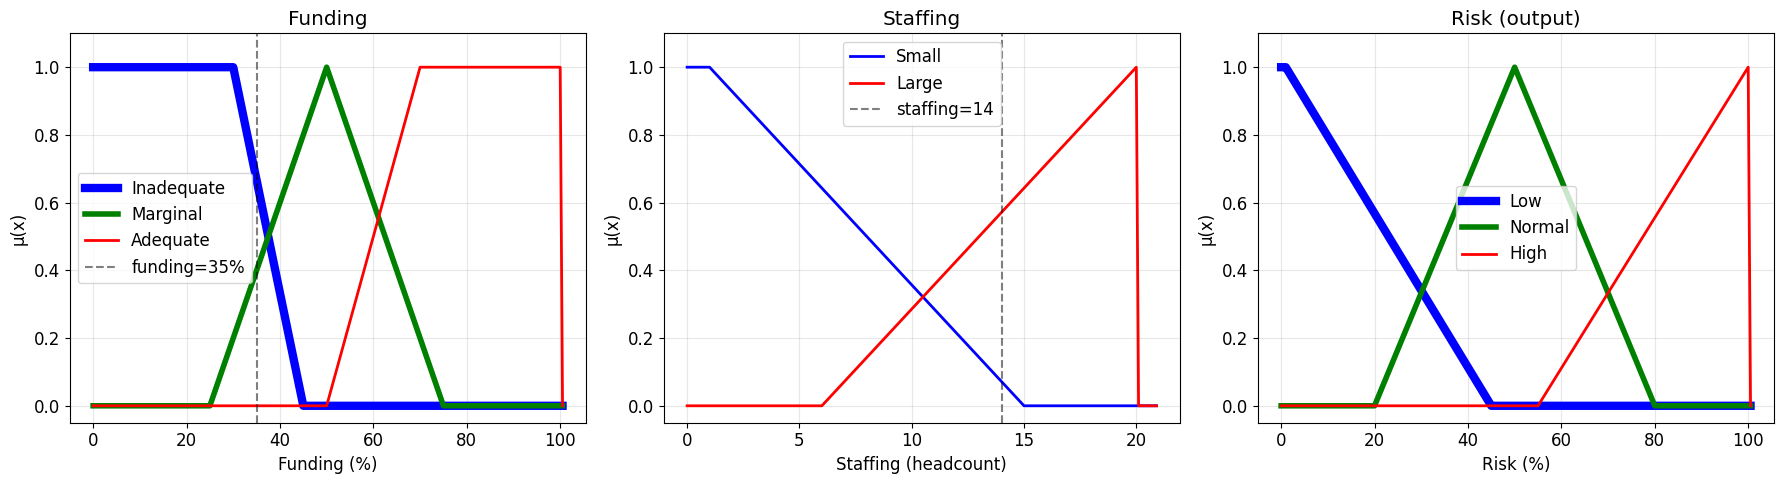

In [5]:
# Universes of discourse
x_fund = np.arange(0, 101, 0.5)
x_staff = np.arange(0, 21, 0.1)
x_risk = np.arange(0, 101, 0.5)

# --- Funding MFs ---
# Inadequate: (0,1)→(30,1)→(45,0) — trapezoidal left-shoulder
fund_inadequate = fuzz.trapmf(x_fund, [0, 0, 30, 45])

# Marginal: triangle (25, 50, 75)
# TODO: create the "marginal" fuzzy set here
# Tip: use skfuzzy's "trimf" function
fund_marginal = fuzz.trimf(x_fund, [25, 50, 75])

# Adequate: (50,0)→(70,1)→(100,1) — trapezoidal right-shoulder
# TODO: create the "adequate" fuzzy set here
fund_adequate = fuzz.trapmf(x_fund, [50, 70, 100, 100])

# --- Staffing MFs ---
# Small: (1,1)→(15,0) left-shoulder trapezoid
# TODO: create the "small" fuzzy set here
staff_small = fuzz.trapmf(x_staff, [0, 0, 1, 15])

# Large: (6,0)→(20,1) right-shoulder trapezoid
# TODO: create the "large" fuzzy set here
staff_large = fuzz.trapmf(x_staff, [6, 20, 20, 20])

# --- Risk MFs ---
# Low: (0,1)→(45,0) left-shoulder trapezoid
# TODO: create the "low" fuzzy set here
risk_low = fuzz.trapmf(x_risk, [0, 0, 1, 45])

# Normal: triangle (20, 50, 80)
# TODO: create the "normal" fuzzy set here
risk_normal = fuzz.trimf(x_risk, [20, 50, 80])

# High: (55,0)→(100,1) right-shoulder trapezoid
# TODO: create the "high" fuzzy set here
risk_high = fuzz.trapmf(x_risk, [55, 100, 100, 100])

# --- Plot ---
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

ax1.plot(x_fund, fund_inadequate, 'b-', lw=6, label='Inadequate')
ax1.plot(x_fund, fund_marginal, 'g-', lw=4, label='Marginal')
ax1.plot(x_fund, fund_adequate, 'r-', lw=2, label='Adequate')
ax1.axvline(x=35, color='k', ls='--', alpha=0.5, label='funding=35%')
ax1.set_title('Funding')
ax1.set_xlabel('Funding (%)')
ax1.set_ylabel('μ(x)')
ax1.legend()

ax2.plot(x_staff, staff_small, 'b-', lw=2, label='Small')
ax2.plot(x_staff, staff_large, 'r-', lw=2, label='Large')
ax2.axvline(x=14, color='k', ls='--', alpha=0.5, label='staffing=14')
ax2.set_title('Staffing')
ax2.set_xlabel('Staffing (headcount)')
ax2.set_ylabel('μ(x)')
ax2.legend()

ax3.plot(x_risk, risk_low, 'b-', lw=6, label='Low')
ax3.plot(x_risk, risk_normal, 'g-', lw=4, label='Normal')
ax3.plot(x_risk, risk_high, 'r-', lw=2, label='High')
ax3.set_title('Risk (output)')
ax3.set_xlabel('Risk (%)')
ax3.set_ylabel('μ(x)')
ax3.legend()

for ax in [ax1, ax2, ax3]:
    ax.set_ylim(-0.05, 1.1)

plt.tight_layout()
plt.show()

### Step 2: Fuzzification 

In [6]:
# Crisp inputs
funding_val = 35
staffing_val = 14

# Fuzzify funding
# Calculate the degree of membership (DoM) for "inadequate"
mu_inadequate = fuzz.interp_membership(x_fund, fund_inadequate, funding_val)

# TODO: Calculate DoM for "marginal" here
mu_marginal = fuzz.interp_membership(x_fund, fund_marginal, funding_val)

# TODO: Calculate DoM for "adequate" here
mu_adequate = fuzz.interp_membership(x_fund, fund_adequate, funding_val)

# Fuzzify staffing
# TODO: Calculate DoM for "small" here
mu_small = fuzz.interp_membership(x_staff, staff_small, staffing_val)

# TODO: Calculate DoM for "large" here
mu_large = fuzz.interp_membership(x_staff, staff_large, staffing_val)

print(f"Fuzzification: funding = {funding_val}%, staffing = {staffing_val}")
print(f"{'─' * 45}")
print(f" μ_inadequate({funding_val}) = {mu_inadequate:.4f}")
print(f" μ_marginal({funding_val}) = {mu_marginal:.4f}")
print(f" μ_adequate({funding_val}) = {mu_adequate:.4f}")
print()
print(f" μ_small({staffing_val}) = {mu_small:.4f}")
print(f" μ_large({staffing_val}) = {mu_large:.4f}")

Fuzzification: funding = 35%, staffing = 14
─────────────────────────────────────────────
 μ_inadequate(35) = 0.6667
 μ_marginal(35) = 0.4000
 μ_adequate(35) = 0.0000

 μ_small(14) = 0.0714
 μ_large(14) = 0.5714


### Step 3: Rule Evaluation

Rule evaluation:
 Rule 1: max(adequate=0.000, small=0.071) = 0.071 → clip 'low'
 Rule 2: min(marginal=0.400, large=0.571) = 0.400 → clip 'normal'
 Rule 3: inadequate = 0.667 → clip 'high'


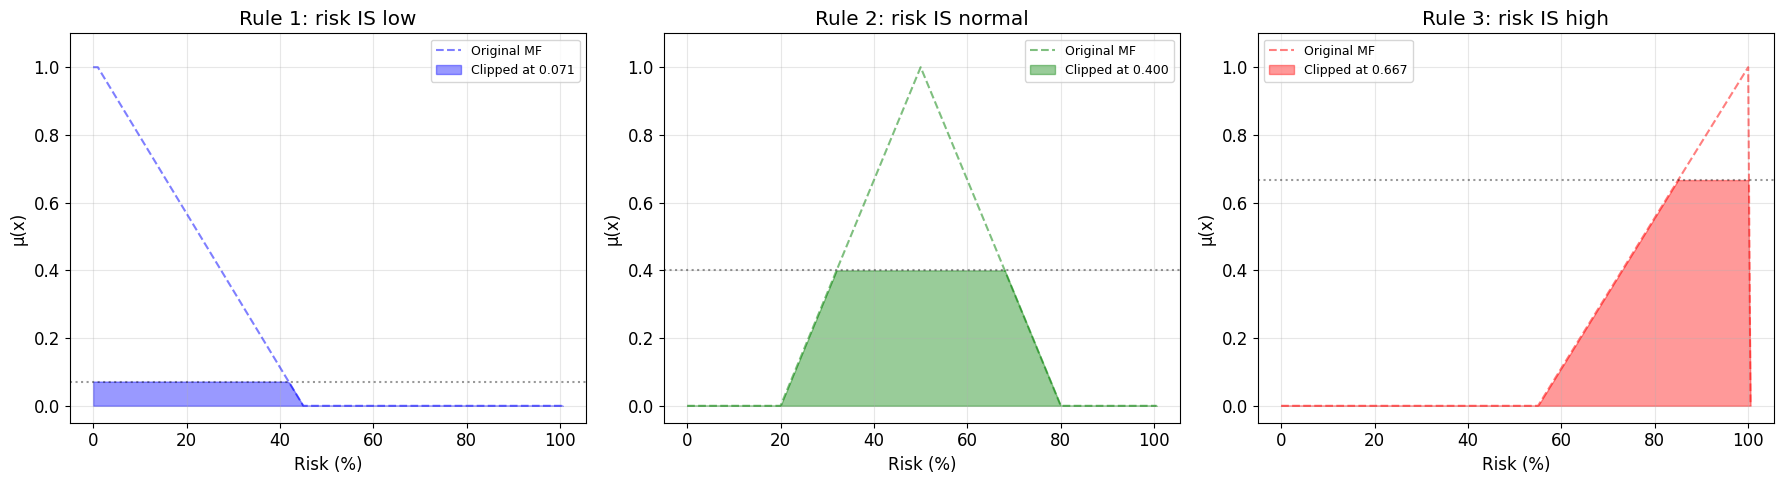

In [7]:
# Rule 1: IF funding IS adequate OR (max) staffing IS small THEN risk IS low
rule1_strength = max(mu_adequate, mu_small)
rule1_output = np.minimum(rule1_strength, risk_low)  # Clip (min-implication)

# Rule 2: IF funding IS marginal AND (min) staffing IS large THEN risk IS normal
# TODO: Code Rule 2 here
rule2_strength = min(mu_marginal, mu_large)
rule2_output = np.minimum(rule2_strength, risk_normal)  # Clip

# Rule 3: IF funding IS inadequate THEN risk IS high
rule3_strength = mu_inadequate
rule3_output = np.minimum(rule3_strength, risk_high)  # Clip

print("Rule evaluation:")
print(
    f" Rule 1: max(adequate={mu_adequate:.3f}, small={mu_small:.3f}) "
    f"= {rule1_strength:.3f} → clip 'low'"
)
print(
    f" Rule 2: min(marginal={mu_marginal:.3f}, large={mu_large:.3f}) "
    f"= {rule2_strength:.3f} → clip 'normal'"
 )
print(f" Rule 3: inadequate = {rule3_strength:.3f} → clip 'high'")

# Plot clipped consequents
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

titles = [
    'Rule 1: risk IS low',
    'Rule 2: risk IS normal',
    'Rule 3: risk IS high',
]
originals = [risk_low, risk_normal, risk_high]
clipped = [rule1_output, rule2_output, rule3_output]
strengths = [rule1_strength, rule2_strength, rule3_strength]
colors = ['blue', 'green', 'red']

for ax, title, orig, clip, strength, color in zip(
    axes, titles, originals, clipped, strengths, colors
):
    ax.plot(
        x_risk,
        orig,
        color=color,
        ls='--',
        lw=1.5,
        alpha=0.5,
        label='Original MF',
    )
    ax.fill_between(
        x_risk,
        clip,
        alpha=0.4,
        color=color,
        label=f'Clipped at {strength:.3f}',
    )
    ax.axhline(y=strength, color='k', ls=':', alpha=0.4)
    ax.set_title(title)
    ax.set_xlabel('Risk (%)')
    ax.set_ylabel('μ(x)')
    ax.set_ylim(-0.05, 1.1)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()